# Homework 6

TFCB 2024

Due date: Nov 14, 2024

In this homework, we will work through a series of manipulations to analyze a published deep sequencing
dataset using `tidyverse` functions.

In the process, we will learn some new functions in `tidyverse` and apply
them to our data analysis.

For more information about the data used in this homework, see
[this page](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE89183).


In [228]:
library(tidyverse)

## Problem 1

**10 points**

For each of the following functions, provide a <100 character description
(in your own words) and a URL reference.

1. `!` # ! signifies not. For example, != would mean not equal to. source: https://rdrr.io/r/base/Logic.html
2. `colnames()` #colnames() will either return or set column names of a matrix or data frame. source: https://rdrr.io/r/base/colnames.html
3. `is.na` #this checks if the element is missing, as na means not available. source: https://rdrr.io/r/base/NA.html
4. `is.numeric` #this checks if the elemtent is numeric. source: https://rdrr.io/cran/h2o/man/is.numeric.html
5. `anti_join` #returns observations that exist in the first passed in data set but are not in the second passed in data set. source: https://www.geeksforgeeks.org/r-language/anti-join-in-r/
6. `desc` #this orders values into descending order. source: https://dplyr.tidyverse.org/reference/desc.html
7. `dplyr::slice` #this allows you to select rows by their position. source: https://dplyr.tidyverse.org/reference/slice.html
8. `dplyr::across` #applies functions to multiple columns allowing you to transform multiple at once. source: https://dplyr.tidyverse.org/reference/across.html



## Problem 2

**10 points**

Add a comment above each code line below explaining what the code line does and/or why
that code line is necessary.

Keep each comment to less than 2 lines per line of code and < 80 chars per line.

In [229]:
#loads in the biomaRt package for accessing the Ensembl database
library(biomaRt)
#connect to the Ensembl database and specify the human genes dataset
mart <- useMart('ensembl', dataset = 'hsapiens_gene_ensembl')
#mart <- useDataset(“hsapiens_gene_ensembl”, mart)

#from biomaRt,retrieves a data frame containing the specified gene attributes
annotations <- getBM(
  #tells getBM() which BioMart database to use
  mart = mart,
  #reterives the selected gene attributes: Ensembl gene ID, HGNC symbol, and CCDS ID
  attributes = c('ensembl_gene_id', 'hgnc_symbol', 'ccds'),
  #removes duplicate rows from the result, %>% pipe passes the result to the next function
  uniqueRows = TRUE) %>%
  #renames the ccds column to ccds_id, pipe passes the result to the next function
  rename(ccds_id = `ccds`) %>%
  #keeps only rows where ccds_id is not empty, pipe passes the result to the next function
  filter(ccds_id != '') %>%
  #print the resulting annotations dataframe
  print()

      ensembl_gene_id     hgnc_symbol   ccds_id
1     ENSG00000183753            BPY2 CCDS14800
2     ENSG00000169953           HSFY2 CCDS35476
3     ENSG00000169953           HSFY2 CCDS14791
4     ENSG00000172468           HSFY1 CCDS35475
5     ENSG00000172468           HSFY1 CCDS14790
6     ENSG00000176679         TGIF2LY CCDS14775
7     ENSG00000182415           CDY2A CCDS14789
8     ENSG00000185894           BPY2C CCDS44030
9     ENSG00000205916            DAZ4 CCDS55557
10    ENSG00000205916            DAZ4 CCDS94720
11    ENSG00000129873           CDY2B CCDS35473
12    ENSG00000184895             SRY CCDS14772
13    ENSG00000129824          RPS4Y1 CCDS14773
14    ENSG00000154620          TMSB4Y CCDS14786
15    ENSG00000129864             VCY CCDS56617
16    ENSG00000187191            DAZ3 CCDS35489
17    ENSG00000188120            DAZ1 CCDS48209
18    ENSG00000188120            DAZ1 CCDS94718
19    ENSG00000099721           AMELY CCDS14778
20    ENSG00000099721           AMELY CC

In [230]:
# reads a tsv file directly from an online FTP link, pipes the result to the next function
data <- read_tsv("ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE89nnn/GSE89183/suppl/GSE89183_Counts.txt.gz") %>%
  #renames the column ENSEMBL gene to ensembl_gene_id, pipes the result to the next function
  rename(ensembl_gene_id = `ENSEMBL gene`) %>%
  #print the loaded data frame
  print()

Rows: 63677 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (1): ENSEMBL gene
dbl (14): CD34_shTSR2_RNA_1, CD34_shTSR2_RNA_2, CD34_shRPL5_RNA_1, CD34_shRP...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# A tibble: 63,677 × 15
   ensembl_gene_id CD34_shTSR2_RNA_1 CD34_shTSR2_RNA_2 CD34_shRPL5_RNA_1
   <chr>                       <dbl>             <dbl>             <dbl>
 1 ENSG00000000003                48                56                40
 2 ENSG00000000005                 0                 2                 0
 3 ENSG00000000419               880               744              1116
 4 ENSG00000000457               124               113               149
 5 ENSG00000000460               249               262               289
 6 ENSG00000000938                89                64               204
 7 ENSG00000000971               106                86               241
 8 ENSG00000001036               897               613              1487
 9 ENSG00000001084               965              1027              1036
10 ENSG00000001167               721               835               498
# … with 63,667 more rows, and 11 more variables: CD34_shRPL5_RNA_2 <dbl>,
#   CD34_shRPL5_RPF_1 <db

## Problem 3

**10 points**

Using the code below:

1. Convert both axes to `log10` instead of linear scales.
2. Show axis tick labels as 10^0^, 10^1^, 10^2^,10^3^, 10^4^, 10^5^ for both axes.
3. There are too many points overlapping in certain regions. Use a different
`geom_` function to convey to your reader how many overlapping points are present
in each region.

Warning message:
“Removed 3 rows containing non-finite values (stat_bin2d).”


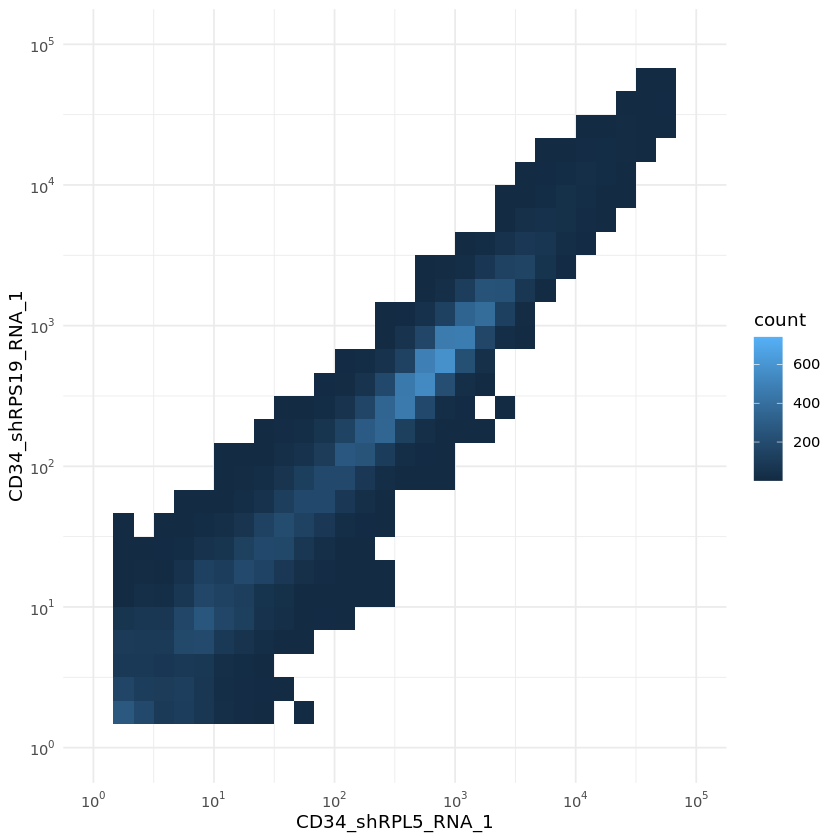

In [231]:

data %>%
  dplyr::select(CD34_shRPL5_RNA_1, CD34_shRPS19_RNA_1) %>%
  filter(CD34_shRPL5_RNA_1 > 0, CD34_shRPS19_RNA_1 > 0) %>%
  filter(!is.na(CD34_shRPL5_RNA_1), !is.na(CD34_shRPS19_RNA_1)) %>%
  ggplot(aes(x = CD34_shRPL5_RNA_1, y = CD34_shRPS19_RNA_1)) +
    # Convert both axes to log10 scale
    scale_x_log10(breaks = 10^(0:5), limits = c(1, 1e5), labels = c(expression(10^0), expression(10^1), expression(10^2), expression(10^3), expression(10^4), expression(10^5))) +
    scale_y_log10(breaks = 10^(0:5), limits = c(1, 1e5), labels = c(expression(10^0), expression(10^1), expression(10^2), expression(10^3), expression(10^4), expression(10^5))) +
    geom_bin2d() +
    theme_minimal()

**In problems 4 through 6, assign the result of your operation back to the `data`
variable.**

Problem 4
10 points

Write a code cell to select the following columns from the data variable you created above and reassign back to data.

Columns to select: ensembl_gene_id, columns that have either RPL5, RPS19, or Luc in their name.

Instead of listing every column, use matches and a succinct regular expression to select the above columns.

In [232]:
data <- data%>%
    dplyr::select(ensembl_gene_id, matches("RPL5|RPS19|Luc")) %>%
    print()

# A tibble: 63,677 × 13
   ensembl_gene_id CD34_shRPL5_RNA_1 CD34_shRPL5_RNA_2 CD34_shRPL5_RPF_1
   <chr>                       <dbl>             <dbl>             <dbl>
 1 ENSG00000000003                40                49                 6
 2 ENSG00000000005                 0                 0                 0
 3 ENSG00000000419              1116              1000               101
 4 ENSG00000000457               149               126                14
 5 ENSG00000000460               289               268                52
 6 ENSG00000000938               204               145                17
 7 ENSG00000000971               241               203                45
 8 ENSG00000001036              1487               936               182
 9 ENSG00000001084              1036              1224               134
10 ENSG00000001167               498               557                75
# … with 63,667 more rows, and 9 more variables: CD34_shRPL5_RPF_2 <dbl>,
#   CD34_shRPS19_RNA_1 <db

## Problem 5

**10 points**

Write a code cell to filter the result from Problem 4 to include only rows where each of the 12 numerical columns you selected has 50 counts or more  and reassign back to `data`.
This is a simple way to avoid genes that have very low counts.

You might be tempted to do this step separately for each of the 12 columns, but instead use the `across` function you learned above or the `pivot_longer` function from the class (either way is fine).

In [233]:
data <- data %>%
  filter(apply(across(2:13, ~ .x >= 50), 1, all)) %>% 
  print()

# A tibble: 4,239 × 13
   ensembl_gene_id CD34_shRPL5_RNA_1 CD34_shRPL5_RNA_2 CD34_shRPL5_RPF_1
   <chr>                       <dbl>             <dbl>             <dbl>
 1 ENSG00000000419              1116              1000               101
 2 ENSG00000001036              1487               936               182
 3 ENSG00000001084              1036              1224               134
 4 ENSG00000001497              1436              1231               253
 5 ENSG00000002549              1228              1186               285
 6 ENSG00000002586              2746              1600               260
 7 ENSG00000002834              4346              3800               254
 8 ENSG00000003056              1379              1661               321
 9 ENSG00000003393               832               690                84
10 ENSG00000003402              1836              1382                95
# … with 4,229 more rows, and 9 more variables: CD34_shRPL5_RPF_2 <dbl>,
#   CD34_shRPS19_RNA_1 <dbl>

## Problem 6

**10 points**

Write a code cell to divide each of the 12 numerical columns by the
corresponding median value for each column
and reassign back to `data`. This median normalization is typically done in
high-throughput experiments after filtering
to normalize for sample-to-sample difference in read depth.

Again, you can write lot less code if you use the `mutate` and `across` function
you learned above.


In [234]:
data <- data %>%
  mutate(across(2:13, ~ as.numeric(.x) / median(as.numeric(.x), na.rm = TRUE))) %>%
  print()

# A tibble: 4,239 × 13
   ensembl_gene_id CD34_shRPL5_RNA_1 CD34_shRPL5_RNA_2 CD34_shRPL5_RPF_1
   <chr>                       <dbl>             <dbl>             <dbl>
 1 ENSG00000000419             0.817             0.832             0.620
 2 ENSG00000001036             1.09              0.779             1.12 
 3 ENSG00000001084             0.758             1.02              0.822
 4 ENSG00000001497             1.05              1.02              1.55 
 5 ENSG00000002549             0.899             0.987             1.75 
 6 ENSG00000002586             2.01              1.33              1.60 
 7 ENSG00000002834             3.18              3.16              1.56 
 8 ENSG00000003056             1.01              1.38              1.97 
 9 ENSG00000003393             0.609             0.574             0.515
10 ENSG00000003402             1.34              1.15              0.583
# … with 4,229 more rows, and 9 more variables: CD34_shRPL5_RPF_2 <dbl>,
#   CD34_shRPS19_RNA_1 <dbl>

## Problem 7

**10 points**

After we do the above filtering and median-normalization, let us calculate
translation efficiency as the average ratio of the RPF and RNA reads for each
treatment condition. Then we calculate how this translation efficiency changes
between target (`rpl5` and `rps19`) and control (`luc`) shRNAs.

The code implementing the above steps is shown below, but it has a few
errors. Correct them.


In [235]:
lfc <- data %>%
  mutate(mean_rpl5_te = ((CD34_shRPL5_RPF_1 + CD34_shRPL5_RPF_2) /
                            (CD34_shRPL5_RNA_1 + CD34_shRPL5_RNA_2))) %>%
  mutate(mean_rps19_te = ((CD34_shRPS19_RPF_1 + CD34_shRPS19_RPF_2) /
                            (CD34_shRPS19_RNA_1 + CD34_shRPS19_RNA_2))) %>%
  mutate(mean_shluc_te = ((CD34_shLuc_RPF_1 + CD34_shLuc_RPF_2) /
                            (CD34_shLuc_RNA_1 + CD34_shLuc_RNA_2))) %>%
  dplyr::select(ensembl_gene_id, mean_rpl5_te, mean_rps19_te, mean_shluc_te) %>%
  mutate(lfc_te_rpl5 = log2(mean_rpl5_te / mean_shluc_te),
         lfc_te_rps19 = log2(mean_rps19_te / mean_shluc_te)) %>%
  print()

# A tibble: 4,239 × 6
   ensembl_gene_id mean_rpl5_te mean_rps19_te mean_shluc_te lfc_te_rpl5
   <chr>                  <dbl>         <dbl>         <dbl>       <dbl>
 1 ENSG00000000419        0.919         1.49          1.08       -0.239
 2 ENSG00000001036        1.17          1.11          1.45       -0.316
 3 ENSG00000001084        1.02          1.14          0.853       0.258
 4 ENSG00000001497        1.38          1.04          1.75       -0.338
 5 ENSG00000002549        1.78          1.87          1.50        0.245
 6 ENSG00000002586        0.903         0.825         1.14       -0.331
 7 ENSG00000002834        0.479         0.394         0.519      -0.115
 8 ENSG00000003056        1.87          1.87          1.02        0.882
 9 ENSG00000003393        0.831         1.20          0.462       0.847
10 ENSG00000003402        0.505         0.427         0.344       0.552
# … with 4,229 more rows, and 1 more variable: lfc_te_rps19 <dbl>


## Problem 8

**10 points**

Write code that will create a new dataframe called `mean_lfc` from `lfc`
containing a new column called `avg_lfc`.
`avg_lfc` should be the average of the log2 fold-change in TE (`lfc_te`) upon
knockdown of RPL5 and RPS19.

Then select only the gene id column and the new column that you just created
(this will be your new dataframe `mean_lfc`).


In [236]:
mean_lfc <- lfc %>%
  mutate(avg_lfc = (lfc_te_rpl5 + lfc_te_rps19) / 2) %>%
  dplyr::select(ensembl_gene_id, avg_lfc) %>%
  print()

# A tibble: 4,239 × 2
   ensembl_gene_id avg_lfc
   <chr>             <dbl>
 1 ENSG00000000419   0.110
 2 ENSG00000001036  -0.355
 3 ENSG00000001084   0.337
 4 ENSG00000001497  -0.543
 5 ENSG00000002549   0.280
 6 ENSG00000002586  -0.396
 7 ENSG00000002834  -0.256
 8 ENSG00000003056   0.880
 9 ENSG00000003393   1.11 
10 ENSG00000003402   0.431
# … with 4,229 more rows



## Problem 9

**10 points**

Write code to join the `mean_lfc` dataframe with the `annotations` dataframe created
at the top of the document and assign back to `mean_lfc`.


In [237]:
mean_lfc <- mean_lfc %>%
  left_join(annotations, by = "ensembl_gene_id") %>%
  print()

# A tibble: 8,842 × 4
   ensembl_gene_id avg_lfc hgnc_symbol ccds_id  
   <chr>             <dbl> <chr>       <chr>    
 1 ENSG00000000419   0.110 DPM1        CCDS82628
 2 ENSG00000000419   0.110 DPM1        CCDS13434
 3 ENSG00000000419   0.110 DPM1        CCDS93059
 4 ENSG00000001036  -0.355 FUCA2       CCDS5200 
 5 ENSG00000001084   0.337 GCLC        CCDS4952 
 6 ENSG00000001084   0.337 GCLC        CCDS75471
 7 ENSG00000001497  -0.543 LAS1L       CCDS55434
 8 ENSG00000001497  -0.543 LAS1L       CCDS14381
 9 ENSG00000001497  -0.543 LAS1L       CCDS55433
10 ENSG00000001497  -0.543 LAS1L       CCDS94622
# … with 8,832 more rows


## Problem 10

**10 points**

1. Write code to select only the bottom 10 genes with the lowest `avg_lfc` and display the gene `symbol`, gene `name` and `avg_lfc` for these genes.
2. Create a figure using `ggplot2` to visualize these results.

Write a few sentences to justify the choices you made when creating your figure.

# A tibble: 10 × 3
   hgnc_symbol ccds_id   avg_lfc
   <chr>       <chr>       <dbl>
 1 H2AC6       CCDS4585    -2.95
 2 H2BC12      CCDS4621    -2.79
 3 RPS15       CCDS12067   -2.27
 4 RPS15       CCDS77210   -2.27
 5 COX8A       CCDS8054    -2.02
 6 RPL18A      CCDS12367   -2.01
 7 RPLP1       CCDS10234   -2.01
 8 RPLP1       CCDS10233   -2.01
 9 H2AX        CCDS8410    -1.86
10 RPS26       CCDS31832   -1.85


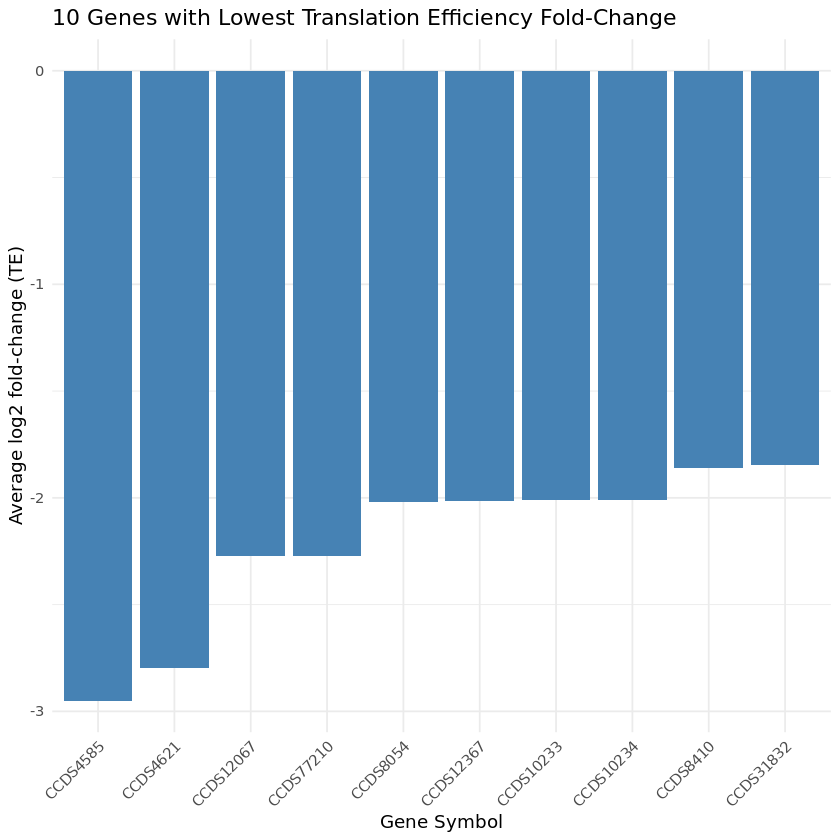

In [239]:
# Select bottom 10 genes
bottom_genes <- mean_lfc %>%
  arrange(avg_lfc) %>%                      # Sort by avg_lfc in ascending order
  slice(1:10) %>%                           # Take the first 10 rows (avg_lfc lowest values)
  dplyr::select(hgnc_symbol, ccds_id, avg_lfc)    # Display gene symbol, gene name (or CCDS ID), and avg_lfc

# Print the bottom genes table
print(bottom_genes)

# Create a figure
ggplot(bottom_genes, aes(x = reorder(ccds_id, avg_lfc), y = avg_lfc)) +
  geom_col(fill = "steelblue") +           # Bar plot
  labs(
    x = "Gene Symbol",
    y = "Average log2 fold-change (TE)",
    title = "10 Genes with Lowest Translation Efficiency Fold-Change"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))  # rotate x-axis labels

# I chose to display the CCDS IDs on the x-axis for clarity, as gene symbols may not be unique. I then rotated the x axis labels so that they would fit uniformly in the figure. 
# I chose to keep the bar plot oriented as it is, in case I wanted to plot the positive values later. I used a minimal theme to keep the focus on the data, since there are not many
# variables in this dataset to begin with. 